In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_excel("/content/Clean_transactions.xlsx")
df.head()

,CustomerID,Frequency,Monetary,Recency
0,12667,1,620.13,0
1,18277,1,110.38,0
2,13464,1,674.68,0
3,16753,1,223.92,0
4,14761,2,255.90,0


In [ ]:
customer_ids = df["CustomerID"]
rfm = df[["Recency", "Frequency", "Monetary"]]

In [ ]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [ ]:
inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)


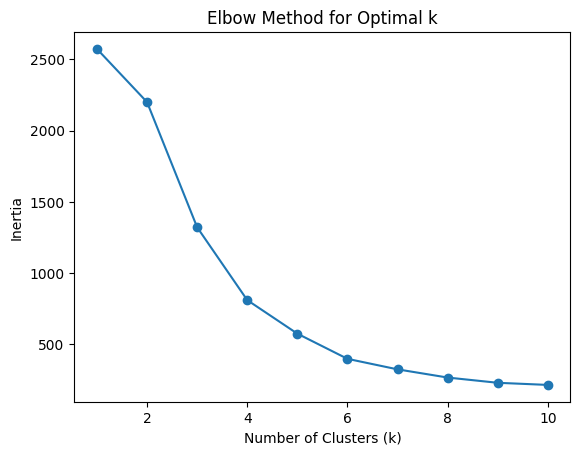

In [ ]:
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(rfm_scaled)


In [ ]:
df["Cluster"] = clusters
df.head()


,CustomerID,Frequency,Monetary,Recency,Cluster
0,12667,1,620.13,0,2
1,18277,1,110.38,0,2
2,13464,1,674.68,0,2
3,16753,1,223.92,0,2
4,14761,2,255.90,0,2


In [ ]:
cluster_summary = df.groupby("Cluster").mean()
cluster_summary


,CustomerID,Frequency,Monetary,Recency
Cluster,,,,
0,15098.000000,3.000000,39916.500000,65.000000
1,15539.712230,1.111511,341.290827,375.928058
2,15203.930796,1.553633,567.522699,114.676471
3,17850.000000,34.000000,5391.210000,666.000000


In [ ]:
cluster_summary = df.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "CustomerCount"})

cluster_summary


,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,65.000000,3.000000,39916.500000,1
1,375.928058,1.111511,341.290827,278
2,114.676471,1.553633,567.522699,578
3,666.000000,34.000000,5391.210000,1


In [ ]:
cluster_counts = df["Cluster"].value_counts().to_dict()
cluster_counts


{2: 578, 1: 278, 0: 1, 3: 1}

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


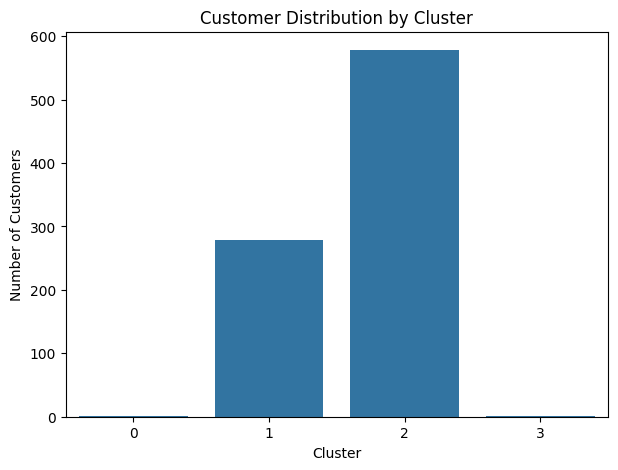

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(
    x=cluster_summary.index,
    y=cluster_summary["CustomerCount"]
)
plt.title("Customer Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()


Cluster 0: High-Value Customer
*   Extremely high monetary value (~₹39k)
*   Moderate activity
*   Only 1 customer

Cluster 1: Churned / Inactive Customers
*   Very high recency → haven’t purchased for a long time
*   Very low frequency → mostly one-time buyers

Cluster 2: Regular Customers
*   Moderate recency
*   Low–moderate frequency
*   Largest group

Cluster 3: Bulk Buyer
*   Extremely high frequency
*   Very old recency

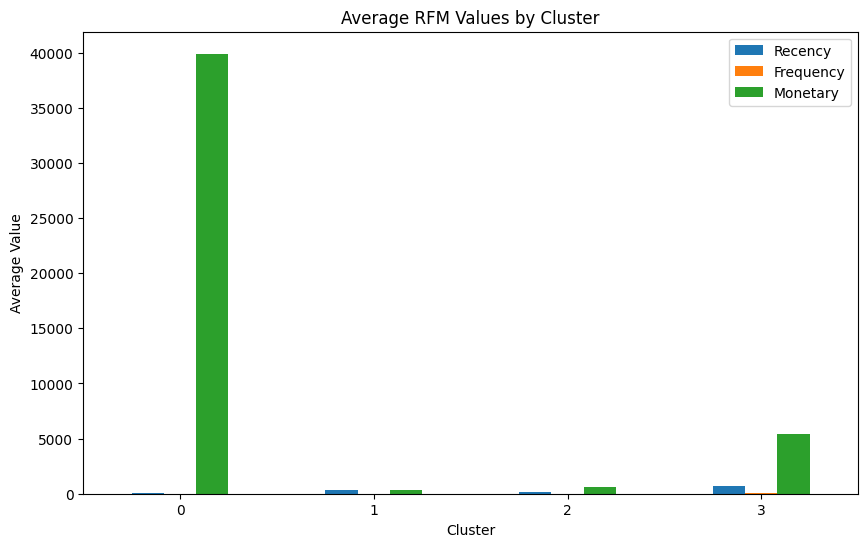

In [ ]:
cluster_summary[["Recency", "Frequency", "Monetary"]].plot(
    kind="bar",
    figsize=(10,6)
)
plt.title("Average RFM Values by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()


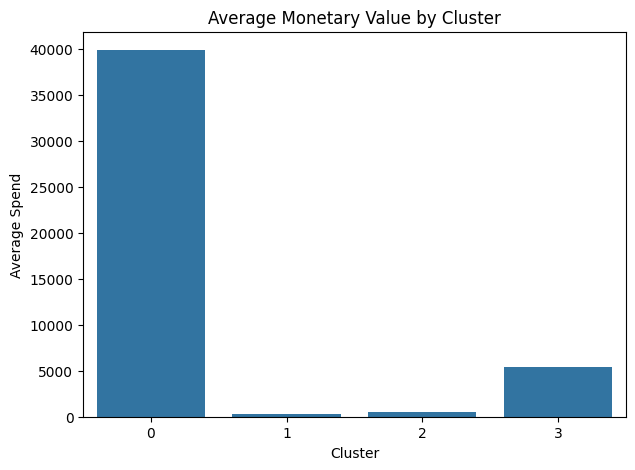

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(
    x=cluster_summary.index,
    y=cluster_summary["Monetary"]
)
plt.title("Average Monetary Value by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Spend")
plt.show()


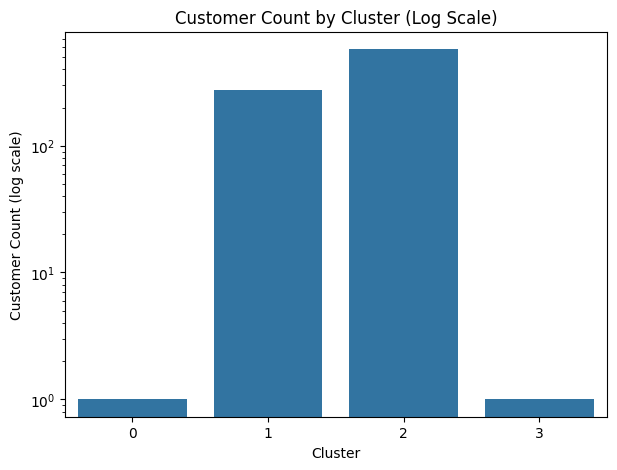

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(
    x=cluster_summary.index,
    y=cluster_summary["CustomerCount"]
)
plt.yscale("log")
plt.title("Customer Count by Cluster (Log Scale)")
plt.xlabel("Cluster")
plt.ylabel("Customer Count (log scale)")
plt.show()


In [ ]:
df.to_csv('clustered_customer_data.csv', index=False)
print('Data with cluster information saved to clustered_customer_data.csv')

Data with cluster information saved to clustered_customer_data.csv
